In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import correlate
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter

# Ustawienie estetyki wykresów 
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 10
%matplotlib inline

In [19]:
# Wczytanie danych o zasięgu lodu morskiego
df = pd.read_csv("daily_ice_edge.zip", compression='zip')
df['Date'] = pd.to_datetime(df['Date'], format="%d-%b-%Y")

# Wyodrębnienie danych o szerokości geograficznej dla wszystkich 360 kątów
ice_data = df.iloc[:, 1:]
ice_data.columns = np.arange(0, 361)
longitudes = np.arange(0, 361).astype(float)

# Przekształcenie danych do formatu "long" w celu ułatwienia modelowania
df_long = df.melt(id_vars='Date', var_name='longitude', value_name='latitude')

# Czyszczenie danych: usunięcie tekstowych prefiksów i sufiksów z kolumny 'longitude'
df_long['longitude'] = df_long['longitude'].astype(str).str.replace('longitude_', '', regex=False)
df_long['longitude'] = df_long['longitude'].astype(str).str.replace('E', '', regex=False)
df_long['longitude'] = df_long['longitude'].astype(int)

# Konwersja czasu do formatu numerycznego (liczba dni od pierwszego pomiaru)
df_long['day_from_start'] = (df_long['Date'] - df['Date'].min()).dt.days

print("Zakończono ładowanie i czyszczenie danych.")
print(f"Liczba przeanalizowanych pomiarów: {len(df_long)}")

Zakończono ładowanie i czyszczenie danych.
Liczba przeanalizowanych pomiarów: 3440330


In [4]:
def fourier_series(t, *coeffs):
    """
    Oblicza wartość funkcji opartej na szeregu Fouriera (5 składowych harmonicznych).
    Wykorzystywane do modelowania rocznej sezonowości zjawisk klimatycznych.
    """
    a0 = coeffs[0]
    result = a0
    N_HARMONICS = 5
    PERIOD = 365 
    for k in range(1, N_HARMONICS + 1):
        ak, bk = coeffs[2*k-1], coeffs[2*k]
        result += ak * np.cos(2 * np.pi * k * t / PERIOD) + bk * np.sin(2 * np.pi * k * t / PERIOD)
    return result

def to_xy(latitudes, longitudes):
    """
    Transformacja współrzędnych sferycznych na płaski układ kartezjański.
    Uwzględnia odpowiednią orientację bieguna południowego (0°E na szczycie wykresu).
    """
    theta = np.radians(longitudes)
    theta = -theta + np.pi/2
    r = 90 + np.array(latitudes) 
    return r * np.cos(theta), r * np.sin(theta)

In [20]:
coeff_dict = {}
fourier_errors = []

print("Optymalizacja parametrów Fouriera dla poszczególnych długości geograficznych.")
for lon in tqdm(longitudes, desc="Trenowanie modeli harmonicznych"):
    sub = df_long[df_long['longitude'] == lon].dropna()
    t_vals, y_vals = sub['day_from_start'].values, sub['latitude'].values
    
    # Inicjalizacja optymalizatora: składowa stała (średnia) oraz zera dla współczynników harmonicznych
    guess = [np.mean(y_vals)] + [0] * 10 
    
    try:
        popt, _ = curve_fit(fourier_series, t_vals, y_vals, p0=guess, maxfev=10000)
        coeff_dict[lon] = popt
        
        # Kalkulacja błędu bezwzględnego (MAE) dla każdego dopasowania
        preds = fourier_series(t_vals, *popt)
        fourier_errors.append(mean_absolute_error(y_vals, preds))
    except RuntimeError:
        # Obsługa wyjątków 
        coeff_dict[lon] = np.array([np.nan] * 11)

print(f"Średni błąd modelu: {np.nanmean(fourier_errors):.2f}°")

Optymalizacja parametrów Fouriera dla poszczególnych długości geograficznych.


Trenowanie modeli harmonicznych:   0%|          | 0/361 [00:00<?, ?it/s]

Średni błąd modelu: 0.95°


In [6]:
# Eliminacja braków danych 
df_ml = df_long.dropna()
X = df_ml[['longitude', 'day_from_start']]
y = df_ml['latitude']

# Podział zbioru na dane treningowe i testowe (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Trenowanie algorytmu Random Forest Regressor.")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Ewaluacja modelu
rf_preds = rf_model.predict(X_test)
print(f"Random Forest R^2 Score (Wyjaśniona wariancja): {r2_score(y_test, rf_preds):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.2f}°")

Trenowanie algorytmu Random Forest Regressor.
Random Forest R^2 Score (Wyjaśniona wariancja): 0.9962
Random Forest MAE: 0.12°


Średni odstęp między pomiarami satelitarnymi: 1.17 dnia
Zidentyfikowane przesunięcie fazowe wynosi: -1.17 dni.


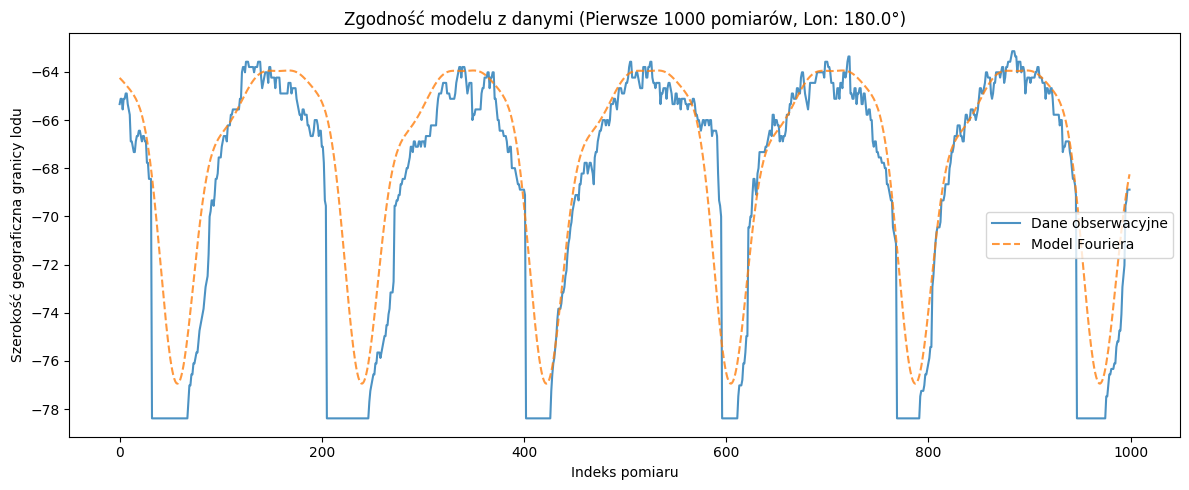

In [11]:
# Obliczenie dokładnych dni od początku pomiarów dla każdego wiersza w danych
days_from_start = (df['Date'] - df['Date'].min()).dt.days.values

# Wybór reprezentatywnego kąta do analizy
example_lon = longitudes[len(longitudes) // 2]
real_vec = ice_data[example_lon].values

# Model obliczany dla rzeczywistych dni pomiarowych
model_vec = np.array([fourier_series(d, *coeff_dict[example_lon]) for d in days_from_start])

# Filtracja braków danych 
valid_mask = ~np.isnan(real_vec)
real_clean = real_vec[valid_mask]
model_clean = model_vec[valid_mask]

# Obliczenie korelacji wzajemnej
corr = correlate(real_clean - np.mean(real_clean), 
                 model_clean - np.mean(model_clean), mode='full')

# Przesunięcie wyrażone w indeksach tablicy
shift_idx = corr.argmax() - (len(real_clean) - 1)

# Skalowanie indeksów na rzeczywisty czas (uwzględnienie brakujących dni w satelicie) 
average_step = np.mean(np.diff(df['Date']).astype('timedelta64[D]').astype(float))
shift_in_days = shift_idx * average_step

print(f"Średni odstęp między pomiarami satelitarnymi: {average_step:.2f} dnia")
print(f"Zidentyfikowane przesunięcie fazowe wynosi: {shift_in_days:.2f} dni.")

# Wizualizacja dopasowania szeregu czasowego z poprawką na przesunięcie 
plt.figure(figsize=(12, 5))
plt.plot(real_clean[:1000], label='Dane obserwacyjne', alpha=0.8)
plt.plot(np.roll(model_clean, shift_idx)[:1000], label='Model Fouriera', alpha=0.8, linestyle='--')
plt.title(f"Zgodność modelu z danymi (Pierwsze 1000 pomiarów, Lon: {example_lon}°)")
plt.xlabel("Indeks pomiaru")
plt.ylabel("Szerokość geograficzna granicy lodu")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Inicjalizacja środowiska rysowania dla matplotlib
fig, ax = plt.subplots(figsize=(7, 7))
line_real, = ax.plot([], [], color='deepskyblue', lw=1.5, label='Obserwacja satelitarna')
line_model, = ax.plot([], [], color='crimson', lw=1.5, label='Aproksymacja matematyczna')
title = ax.set_title("", fontsize=12)

ax.set_aspect('equal')
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.axis('off')
ax.legend(loc='upper right')

def update(frame):
    # Obliczamy rzeczywisty dzień od początku pomiarów
    current_day = (df['Date'].iloc[frame] - df['Date'].min()).days
    
    # Przetwarzanie danych wejściowych 
    day_data = ice_data.iloc[frame].dropna()
    xr, yr = to_xy(day_data.values, day_data.index.astype(float))
    
    # Przetwarzanie predykcji modelu 
    lats_m = [fourier_series(current_day, *coeff_dict[lon]) for lon in longitudes]
    xm, ym = to_xy(lats_m, longitudes)
    
    line_real.set_data(xr, yr)
    line_model.set_data(xm, ym)
    title.set_text(f"Zasięg lodu morskiego: {df['Date'].iloc[frame].date()}")
    return line_real, line_model, title

print("Renderowanie animacji GIF.")

# Animacji dla całego zakresu lat 1978-2009 
#TOTAL_FRAMES = len(df_long['Date'].unique())

# Animacja generowana tylko dla pierwszych 100 dni 
#TOTAL_FRAMES = 100

TOTAL_FRAMES = 1095

ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, blit=True)
ani.save("ice_edge_dynamics.gif", writer=PillowWriter(fps=10))

plt.close()
# Animacja zapisana w folderze roboczym

Renderowanie animacji GIF.
